# Análisis exploratorio: Colombianos detenidos en el exterior

| Campo | Valor |
|-------|-------|
| Fuente | Ministerio de Relaciones Exteriores (Cancillería), vía datos.gov.co |
| URL | https://www.datos.gov.co/Estad-sticas-Nacionales/Colombianos-detenidos-en-el-exterior/e97j-vuf7/about_data |
| Fecha de descarga | 28 de septiembre de 2026 |
| Tamaño | 388.148 filas x 12 columnas |
| Cobertura | 17/09/2018 a 01/11/2025, 64 fechas de publicación |
| Granularidad | Cada fila es un grupo de personas (CANTIDAD) con las mismas características, dentro de una foto publicada en una fecha. |

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [61]:
# low_memory=False evita el DtypeWarning: el archivo es grande y pandas
# adivinaría tipos por pedazos. Así lo lee completo antes de decidir.
df = pd.read_csv('Colombianos_detenidos_en_el_exterior_20260928.csv', low_memory=False)
df_original = df.copy()   # copia intacta para comparar "antes y después" al final

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 388148
Columnas: 12


In [62]:
fechas = pd.to_datetime(df['FECHA PUBLICACIÓN'])
print("Primera publicación:", fechas.min().date())
print("Última publicación: ", fechas.max().date())
print("Fechas distintas:   ", fechas.nunique())

por_fecha = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].agg(personas='sum', filas='size')
print()
print(por_fecha.head(3))
print(por_fecha.tail(3))
print()
print("Suma de CANTIDAD en TODAS las fechas:", f"{df['CANTIDAD'].sum():,}")
print("Suma de CANTIDAD en la última fecha: ", f"{por_fecha['personas'].iloc[-1]:,}")

Primera publicación: 2018-09-17
Última publicación:  2025-11-01
Fechas distintas:    64

                   personas  filas
FECHA PUBLICACIÓN                 
2018-09-17            23284   4845
2019-01-01            24232   4997
2019-07-04            25307   5206
                   personas  filas
FECHA PUBLICACIÓN                 
2025-09-01            27911   6124
2025-10-01            27804   6115
2025-11-01            27586   6117

Suma de CANTIDAD en TODAS las fechas: 1,862,305
Suma de CANTIDAD en la última fecha:  27,586


## Justificación de granularidad y carga

**Justificación de granularidad:**

Cada fila del dataset no representa a una persona individual, sino un grupo consolidado de personas (CANTIDAD) que comparten las mismas características categóricas dentro de una fecha de publicación específica. El dataset contiene 64 "fotos" o reportes periódicos entre 2018 y 2025.

**Decisión:** se determina que la columna CANTIDAD no debe sumarse de forma global a través de todas las fechas de publicación, ya que esto incurriría en un conteo múltiple de las mismas personas a lo largo del tiempo. Para análisis puntuales de estado actual se tomará la última foto disponible (27.586 personas), mientras que para análisis de evolución se comparará el total de cada foto por separado.

In [63]:
df.info()
df.head(3).T   # .T gira la tabla: cada columna queda como fila y se lee mejor

<class 'pandas.DataFrame'>
RangeIndex: 388148 entries, 0 to 388147
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   FECHA PUBLICACIÓN           388148 non-null  str  
 1   PAIS PRISIÓN                388148 non-null  str  
 2   CONSULADO                   388148 non-null  str  
 3   DELITO                      388148 non-null  str  
 4   EXTRADITADO Y O REPATRIADO  388148 non-null  str  
 5   SITUACIÓN JURÍDICA          388148 non-null  str  
 6   GÉNERO                      388148 non-null  str  
 7   GRUPO EDAD                  388148 non-null  str  
 8   UBICACIÓN PAÍS              121827 non-null  str  
 9   CANTIDAD                    388148 non-null  int64
 10  LATITUD                     335420 non-null  str  
 11  LONGITUD                    335420 non-null  str  
dtypes: int64(1), str(11)
memory usage: 76.5 MB


,0,1,2
FECHA PUBLICACIÓN,2018-09-17,2018-09-17,2018-09-17
PAIS PRISIÓN,ECUADOR,ITALIA,ESTADOS UNIDOS
CONSULADO,C. QUITO,C. ROMA,C. NUEVA YORK
DELITO,NARCOTRÁFICO,OTROS,EXTORSIÓN
EXTRADITADO Y O REPATRIADO,DESCONOCIDO,DESCONOCIDO,DESCONOCIDO
SITUACIÓN JURÍDICA,EN JUICIO,EN INVESTIGACIÓN,CONDENADO
GÉNERO,MASCULINO,MASCULINO,MASCULINO
GRUPO EDAD,DESCONOCIDO,DESCONOCIDO,ADULTO
UBICACIÓN PAÍS,"(-1.831239, -78.183406)","(41.87194, 12.56738)","(37.09024, -95.712891)"
CANTIDAD,45,1,1


In [64]:
# Nulos que pandas sí ve
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(1)
print(pd.DataFrame({'nulos': nulos, '%': pct})[nulos > 0])

# Duplicados exactos
print("\nDuplicados:", df.duplicated().sum())

# Nulos disfrazados: pandas NO los cuenta, pero lo son
print("\n'DESCONOCIDO' por columna:")
for col in df.select_dtypes(exclude='number').columns:
    k = (df[col].astype(str).str.strip().str.upper() == 'DESCONOCIDO').sum()
    if k > 0:
        print(f"  {col}: {k:,} ({k/len(df)*100:.1f}%)")

                 nulos     %
UBICACIÓN PAÍS  266321 68.60
LATITUD          52728 13.60
LONGITUD         52728 13.60

Duplicados: 32598

'DESCONOCIDO' por columna:
  PAIS PRISIÓN: 230,170 (59.3%)
  DELITO: 38,984 (10.0%)
  EXTRADITADO Y O REPATRIADO: 365,621 (94.2%)
  GÉNERO: 267 (0.1%)
  GRUPO EDAD: 115,356 (29.7%)


In [65]:
for col in ['EXTRADITADO Y O REPATRIADO', 'SITUACIÓN JURÍDICA', 'GÉNERO', 'GRUPO EDAD']:
    print(f"\n{col}")
    print(df[col].value_counts())


EXTRADITADO Y O REPATRIADO
EXTRADITADO Y O REPATRIADO
DESCONOCIDO                  365621
EXTRADICION                   21833
REPATRIACION                    585
EXTRADICION, REPATRIACION       109
Name: count, dtype: int64

SITUACIÓN JURÍDICA
SITUACIÓN JURÍDICA
CONDENADO                                163103
EN INVESTIGACI�N                          97306
EN JUICIO                                 55427
EN INVESTIGACIÓN                          44378
NO REPORTA - CONFIDENCIALIDAD ESTATAL     12403
EN ESPERA DE DEPORTACI�N                  10171
EN ESPERA DE DEPORTACIÓN                   4047
EXTRADITADO                                1313
Name: count, dtype: int64

GÉNERO
GÉNERO
MASCULINO      305646
FEMENINO        81804
OTRO              410
DESCONOCIDO       267
NO_BINARIO         21
Name: count, dtype: int64

GRUPO EDAD
GRUPO EDAD
ADULTO              172852
DESCONOCIDO         115356
ADULTO JOVEN         50805
ADULTO MAYOR         45522
PRIMERA INFANCIA      1548
ADOLESCENTE      

In [66]:
df['CANTIDAD'].describe()

count   388,148.00
mean          4.80
std          16.87
min           1.00
25%           1.00
50%           1.00
75%           3.00
max         460.00
Name: CANTIDAD, dtype: float64

## Diagnóstico inicial

Antes de modificar nada, la inspección mostró varios problemas:

- **Nulos reales:** `UBICACIÓN PAÍS` (68,6 %) y `LATITUD` y `LONGITUD` (13,6 %).
- **Nulos disfrazados:** `DESCONOCIDO` no lo detecta `isnull()` porque es texto. Afecta a `EXTRADITADO Y O REPATRIADO` (94,2 %), `PAIS PRISIÓN` (59,3 %), `GRUPO EDAD` (29,7 %) y `DELITO` (10,0 %).
- **Duplicados exactos:** 32.598 filas (8,4 %).
- **Texto dañado:** categorías partidas en dos por un carácter corrupto (por ejemplo `EN INVESTIGACIÓN` y `EN INVESTIGACI�N`).
- **Tipos mal guardados:** la fecha y las coordenadas venían como texto.
- **`CANTIDAD`:** muy sesgada (mediana 1, promedio 4,8, máximo 460). Es la única variable numérica real.

In [67]:
# '\ufffd' es el carácter de reemplazo: aparece cuando el archivo original perdió una tilde o una Ñ
for col in df.select_dtypes(exclude='number').columns:
    malos = df[col].str.contains('\ufffd', na=False)
    if malos.any():
        print(f"\n{col}: {malos.sum():,} filas afectadas")
        print(df.loc[malos, col].value_counts())


PAIS PRISIÓN: 8,216 filas afectadas
PAIS PRISIÓN
ESPA�A     7930
CURA�AO     286
Name: count, dtype: int64

CONSULADO: 712 filas afectadas
CONSULADO
C. PUERTO ESPA�A    712
Name: count, dtype: int64

DELITO: 79,877 filas afectadas
DELITO
NARCOTR�FICO                             61954
NO REPORTA � CONFIDENCIALIDAD ESTATAL     8276
EXTORSI�N                                 4351
CONDUCCI�N TEMERARIA                      1624
DA�OS                                     1501
FALSIFICACI�N                             1341
DELITOS POL�TICOS                          381
COACCI�N                                   344
CELEBRACI�N INDEBIDA DE CONTRATOS          105
Name: count, dtype: int64

SITUACIÓN JURÍDICA: 107,477 filas afectadas
SITUACIÓN JURÍDICA
EN INVESTIGACI�N            97306
EN ESPERA DE DEPORTACI�N    10171
Name: count, dtype: int64


In [68]:
arreglos = {
    'ESPA�A': 'ESPAÑA', 'CURA�AO': 'CURAÇAO', 'C. PUERTO ESPA�A': 'C. PUERTO ESPAÑA',
    'NARCOTR�FICO': 'NARCOTRÁFICO', 'EXTORSI�N': 'EXTORSIÓN',
    'NO REPORTA � CONFIDENCIALIDAD ESTATAL': 'NO REPORTA - CONFIDENCIALIDAD ESTATAL',
    'CONDUCCI�N TEMERARIA': 'CONDUCCIÓN TEMERARIA', 'DA�OS': 'DAÑOS',
    'FALSIFICACI�N': 'FALSIFICACIÓN', 'DELITOS POL�TICOS': 'DELITOS POLÍTICOS',
    'COACCI�N': 'COACCIÓN', 'CELEBRACI�N INDEBIDA DE CONTRATOS': 'CELEBRACIÓN INDEBIDA DE CONTRATOS',
    'EN INVESTIGACI�N': 'EN INVESTIGACIÓN', 'EN ESPERA DE DEPORTACI�N': 'EN ESPERA DE DEPORTACIÓN',
}
cols_texto = ['PAIS PRISIÓN', 'CONSULADO', 'DELITO', 'SITUACIÓN JURÍDICA']

antes = {c: df[c].nunique() for c in cols_texto}
df[cols_texto] = df[cols_texto].replace(arreglos)

for c in cols_texto:
    print(f"{c}: {antes[c]} -> {df[c].nunique()} categorías")

PAIS PRISIÓN: 93 -> 91 categorías
CONSULADO: 121 -> 120 categorías
DELITO: 40 -> 32 categorías
SITUACIÓN JURÍDICA: 8 -> 6 categorías


In [69]:
# Fecha: de texto a fecha real
df['FECHA PUBLICACIÓN'] = pd.to_datetime(df['FECHA PUBLICACIÓN'])

# Latitud y longitud: vienen como texto con coma decimal ("-1,831239")
for c in ['LATITUD', 'LONGITUD']:
    nulos_antes = df[c].isna().sum()
    df[c] = pd.to_numeric(df[c].str.replace(',', '.'), errors='coerce')
    print(f"{c}: nulos antes {nulos_antes:,} | después {df[c].isna().sum():,}")

print(df[['FECHA PUBLICACIÓN', 'LATITUD', 'LONGITUD']].dtypes)

LATITUD: nulos antes 52,728 | después 52,728
LONGITUD: nulos antes 52,728 | después 52,728
FECHA PUBLICACIÓN    datetime64[us]
LATITUD                     float64
LONGITUD                    float64
dtype: object


## Justificación de texto dañado y tipos de datos

**Caracteres corruptos (�):** se identificó pérdida de tildes y de la letra Ñ por inconsistencias de codificación de origen en 4 columnas. Se optó por una corrección mediante diccionario explícito en lugar de eliminar filas, rescatando más de 100.000 registros e integrando categorías duplicadas (por ejemplo: NARCOTR�FICO a NARCOTRÁFICO y EN INVESTIGACI�N a EN INVESTIGACIÓN).

**Conversión de tipos:** FECHA PUBLICACIÓN se transformó a datetime64 para posibilitar agrupaciones temporales. Las coordenadas (LATITUD y LONGITUD) venían en formato de texto con coma decimal; se convirtieron a float64 previa sustitución de comas por puntos. Se usó `errors='coerce'` y se verificó comparando los nulos antes y después (52.728), garantizando que no se destruyó información válida.

In [70]:
dup = df[df.duplicated()]
print(dup.groupby('FECHA PUBLICACIÓN').size().sort_values(ascending=False))

FECHA PUBLICACIÓN
2022-01-24    27005
2023-01-04     5591
2025-10-01        1
2025-11-01        1
dtype: int64


In [71]:
cargas_repetidas = pd.to_datetime(['2022-01-24', '2023-01-04'])
en_cargas = df['FECHA PUBLICACIÓN'].isin(cargas_repetidas)

filas_antes = len(df)
df = df[~(df.duplicated() & en_cargas)]   # borra duplicados SOLO en esas 2 fechas
print(f"Filas: {filas_antes:,} -> {len(df):,}")

por_fecha = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].agg(personas='sum', filas='size')
print(por_fecha.loc[cargas_repetidas])
print(por_fecha['personas'].describe())

Filas: 388,148 -> 355,552
            personas  filas
2022-01-24     26869   5401
2023-01-04     27918   5591
count       64.00
mean    26,563.16
std        797.29
min     23,284.00
25%     26,262.75
50%     26,483.00
75%     26,940.50
max     28,058.00
Name: personas, dtype: float64


## Justificación del tratamiento de duplicados

**Justificación de eliminación de duplicados:**

Se detectaron 32.598 filas duplicadas exactas. Al analizar su distribución temporal, se halló que el 99,99 % de ellas pertenecían a dos fechas específicas:

- **24/01/2022:** 27.005 duplicados (la foto se cargó 6 veces de forma idéntica).
- **04/01/2023:** 5.591 duplicados (la foto se cargó 2 veces).

**Decisión:** se eliminaron los duplicados pertenecientes únicamente a estas dos fechas de carga errónea, reduciendo el dataset de 388.148 a 355.552 filas. Esta limpieza estabilizó el volumen por foto en el rango esperado (entre 23.284 y 28.058 personas por publicación) sin alterar la representatividad de las demás fechas.

Los otros 2 duplicados (uno del 01/10/2025 y otro del 01/11/2025) se conservaron a propósito: dentro de una foto normal, dos filas iguales pueden ser grupos legítimos de personas con las mismas características, y eliminarlas cambiaría el total de esa foto sin una razón clara.

In [72]:
anio = df['FECHA PUBLICACIÓN'].dt.year
total = df.groupby(anio)['CANTIDAD'].sum()
desc = df[df['PAIS PRISIÓN'] == 'DESCONOCIDO'].groupby(anio)['CANTIDAD'].sum()
print((desc / total * 100).round(1))   # % de personas con país desconocido, por año

FECHA PUBLICACIÓN
2018    9.30
2019   12.60
2020   15.60
2021   17.20
2022   28.30
2023   95.00
2024   95.60
2025   95.30
Name: CANTIDAD, dtype: float64


## Hallazgo sobre el registro de país y ubicación

**Hallazgo sobre incompletitud estructural de variables:**

Al evaluar los nulos en PAIS PRISIÓN, se observó un cambio drástico en la metodología de reporte estatal:

- Entre 2018 y 2022 el país de prisión casi siempre se reportaba: el porcentaje de personas con país `DESCONOCIDO` pasó de 9,3 % (2018) a 28,9 % (2022).
- A partir de 2023 el país de prisión no se reporta en ningún registro: el 100 % de las personas aparece con país `DESCONOCIDO`. Esto incluye las filas que traían `EXTRADICION` o `REPATRIACION` en vez de un país, que no son países y se reasignaron a `DESCONOCIDO`.

**Decisión:** no se imputarán ni eliminarán estos registros para no distorsionar el volumen total. Para análisis del país de estancia actual se utilizará la columna CONSULADO (completitud del 100 %), mientras que para análisis específicos por país de prisión se acotará el rango temporal al periodo 2018–2022.

In [73]:
anio = df['FECHA PUBLICACIÓN'].dt.year

# % de filas con UBICACIÓN PAÍS con dato, por año
print((df['UBICACIÓN PAÍS'].notna().groupby(anio).mean() * 100).round(0))

# % de filas con LATITUD nula, por año
print((df['LATITUD'].isna().groupby(anio).mean() * 100).round(0))

# Coordenadas (0, 0): ¿cuántas y en qué años?
ceros = (df['LATITUD'] == 0) & (df['LONGITUD'] == 0)
print("\nFilas con (0, 0):", ceros.sum())
print(ceros.groupby(anio).sum())

FECHA PUBLICACIÓN
2018   100.00
2019   100.00
2020   100.00
2021   100.00
2022     0.00
2023     0.00
2024     0.00
2025     0.00
Name: UBICACIÓN PAÍS, dtype: float64
FECHA PUBLICACIÓN
2018    0.00
2019    0.00
2020    0.00
2021    0.00
2022    3.00
2023   26.00
2024   27.00
2025   28.00
Name: LATITUD, dtype: float64

Filas con (0, 0): 39352
FECHA PUBLICACIÓN
2018      831
2019     3213
2020    13516
2021    10219
2022    11573
2023        0
2024        0
2025        0
dtype: int64


In [74]:
con_ubic = df['UBICACIÓN PAÍS'].notna()
print("Filas con UBICACIÓN:", con_ubic.sum())
print("...y con LATITUD nula en esas filas:", df.loc[con_ubic, 'LATITUD'].isna().sum())

Filas con UBICACIÓN: 121827
...y con LATITUD nula en esas filas: 0


In [75]:
cols_antes = df.shape[1]
df = df.drop(columns='UBICACIÓN PAÍS')

ceros = (df['LATITUD'] == 0) & (df['LONGITUD'] == 0)
df.loc[ceros, ['LATITUD', 'LONGITUD']] = np.nan

print("Columnas:", cols_antes, "->", df.shape[1])
print("Coordenadas nulas ahora:", df['LATITUD'].isna().sum())

Columnas: 12 -> 11
Coordenadas nulas ahora: 90594


In [76]:
no_paises = df['PAIS PRISIÓN'].isin(['EXTRADICION', 'REPATRIACION'])
print("Filas con un estado en vez de país:", no_paises.sum())
print(df.loc[no_paises, 'EXTRADITADO Y O REPATRIADO'].value_counts())

# ¿La info ya está en la otra columna, fila por fila?
print("Coinciden con EXTRADITADO:",
      (df.loc[no_paises, 'PAIS PRISIÓN'] == df.loc[no_paises, 'EXTRADITADO Y O REPATRIADO']).sum())

df.loc[no_paises, 'PAIS PRISIÓN'] = 'DESCONOCIDO'

Filas con un estado en vez de país: 10626
EXTRADITADO Y O REPATRIADO
EXTRADICION     10429
REPATRIACION      197
Name: count, dtype: int64
Coinciden con EXTRADITADO: 10626


In [77]:
for col in ['EXTRADITADO Y O REPATRIADO', 'GRUPO EDAD', 'DELITO']:
    pct = (df[col].eq('DESCONOCIDO').groupby(anio).mean() * 100).round(0)
    print(f"\n{col}: % de filas DESCONOCIDO por año")
    print(pct.to_dict())


EXTRADITADO Y O REPATRIADO: % de filas DESCONOCIDO por año
{2018: 93.0, 2019: 94.0, 2020: 94.0, 2021: 94.0, 2022: 94.0, 2023: 94.0, 2024: 95.0, 2025: 94.0}

GRUPO EDAD: % de filas DESCONOCIDO por año
{2018: 29.0, 2019: 29.0, 2020: 30.0, 2021: 30.0, 2022: 31.0, 2023: 29.0, 2024: 29.0, 2025: 29.0}

DELITO: % de filas DESCONOCIDO por año
{2018: 10.0, 2019: 10.0, 2020: 10.0, 2021: 10.0, 2022: 10.0, 2023: 10.0, 2024: 10.0, 2025: 10.0}


## Justificación del tratamiento de nulos y valores desconocidos

**`UBICACIÓN PAÍS` (eliminada):** tiene datos en el 100 % de las filas de 2018 a 2021 y en el 0 % desde 2022, es decir, la columna dejó de llenarse. Además, cuando tiene dato, `LATITUD` y `LONGITUD` también lo tienen, por lo que solo repite información. Por ser redundante y estar vacía por un motivo estructural, se eliminó (de 12 a 11 columnas).

**Coordenadas `(0, 0)` (convertidas a nulo):** 39.352 filas, todas entre 2018 y 2022. Es un valor de relleno y no un lugar real. Desde 2023 la ubicación desconocida viene como nulo, así que se unificaron ambas formas. No se borraron filas (conservan información válida en las demás columnas) ni se imputaron coordenadas (se inventarían ubicaciones).

**Estados en la columna de país (reasignados):** 10.626 filas tenían `EXTRADICION` o `REPATRIACION` en `PAIS PRISIÓN`, que no son países. En todas, la columna `EXTRADITADO Y O REPATRIADO` ya dice lo mismo, así que no se pierde información. Se pasaron a `DESCONOCIDO`.

**`DESCONOCIDO` en las demás columnas (conservado):** en `EXTRADITADO` (93 % a 95 %), `GRUPO EDAD` (29 % a 31 %) y `DELITO` (10 %) el porcentaje es estable todos los años, o sea que no hay un quiebre como el del país. Como no sabemos si significa "no aplica" o "no reportado", no se imputa ni se elimina: se mantiene como categoría y se interpreta con cautela.

In [78]:
c = df['CANTIDAD']
print("Filas:", f"{len(c):,}")
print("Media:", round(c.mean(), 2), "| Mediana:", c.median())
print("Desv. estándar:", round(c.std(), 2), "| Asimetría:", round(c.skew(), 2))
print("Mín:", c.min(), "| Máx:", c.max())
print("Percentiles 25, 75, 90, 99:", c.quantile([.25, .75, .90, .99]).tolist())
print("% de filas con CANTIDAD = 1:", round((c == 1).mean() * 100, 1))

Filas: 355,552
Media: 4.78 | Mediana: 1.0
Desv. estándar: 16.78 | Asimetría: 12.14
Mín: 1 | Máx: 460
Percentiles 25, 75, 90, 99: [1.0, 3.0, 8.0, 58.0]
% de filas con CANTIDAD = 1: 55.7


In [79]:
def limites_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lim_inf, lim_sup = limites_iqr(c)
atipicos = c[c > lim_sup]

print(f"Límite superior: {lim_sup}")
print(f"Atípicos: {len(atipicos):,} filas ({len(atipicos)/len(c)*100:.1f} % de las filas)")
print(f"Concentran el {atipicos.sum()/c.sum()*100:.1f} % de las personas")

Límite superior: 6.0
Atípicos: 43,679 filas (12.3 % de las filas)
Concentran el 67.9 % de las personas


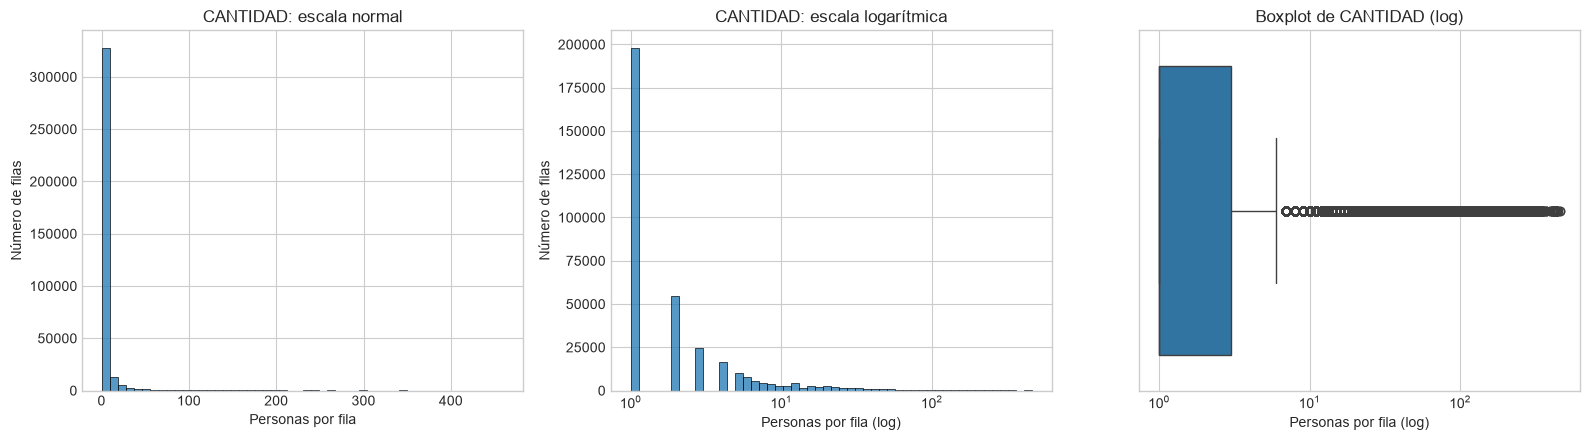

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(c, bins=50, ax=axes[0])
axes[0].set_title('CANTIDAD: escala normal')
axes[0].set_xlabel('Personas por fila'); axes[0].set_ylabel('Número de filas')

sns.histplot(c, bins=50, log_scale=True, ax=axes[1])
axes[1].set_title('CANTIDAD: escala logarítmica')
axes[1].set_xlabel('Personas por fila (log)'); axes[1].set_ylabel('Número de filas')

sns.boxplot(x=c, ax=axes[2])
axes[2].set_xscale('log')
axes[2].set_title('Boxplot de CANTIDAD (log)')
axes[2].set_xlabel('Personas por fila (log)')

plt.tight_layout(); plt.show()

count       64.00
mean    26,563.00
std        797.00
min     23,284.00
25%     26,263.00
50%     26,483.00
75%     26,940.00
max     28,058.00
Name: CANTIDAD, dtype: float64

Fotos atípicas:
FECHA PUBLICACIÓN
2018-09-17    23284
2019-01-01    24232
2022-12-05    28058
Name: CANTIDAD, dtype: int64


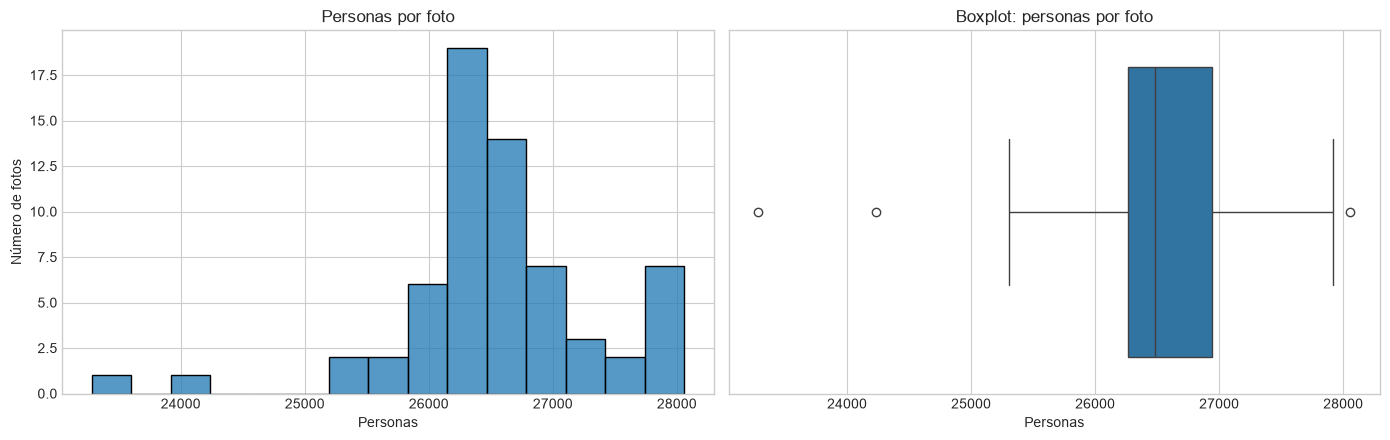

In [81]:
por_foto = df.groupby('FECHA PUBLICACIÓN')['CANTIDAD'].sum()
print(por_foto.describe().round(0))

lim_inf, lim_sup = limites_iqr(por_foto)
print("\nFotos atípicas:")
print(por_foto[(por_foto < lim_inf) | (por_foto > lim_sup)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(por_foto, bins=15, ax=axes[0])
axes[0].set_title('Personas por foto')
axes[0].set_xlabel('Personas'); axes[0].set_ylabel('Número de fotos')
sns.boxplot(x=por_foto, ax=axes[1])
axes[1].set_title('Boxplot: personas por foto'); axes[1].set_xlabel('Personas')
plt.tight_layout(); plt.show()

Consulados: 117
count     117.00
mean      236.00
std       457.00
min         1.00
25%        20.00
50%        59.00
75%       253.00
max     3,391.00
Name: CANTIDAD, dtype: float64

Top 6:
CONSULADO
C. MADRID           3391
C. PANAMA           2301
C. SANTIAGO         1644
C. SAN CRISTOBAL    1106
C. LIMA             1065
C. MEXICO           1037
Name: CANTIDAD, dtype: int64

Top 5 concentran: 34.5 %
Top 10 concentran: 51.0 %


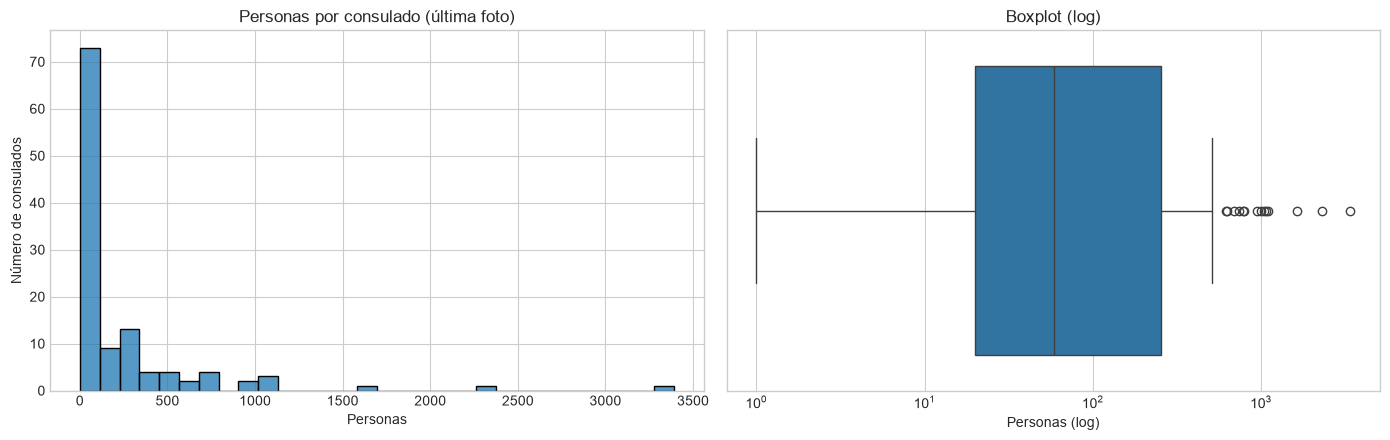

Consulados atípicos: 14


In [82]:
ultima = df[df['FECHA PUBLICACIÓN'] == df['FECHA PUBLICACIÓN'].max()]
por_consulado = ultima.groupby('CONSULADO')['CANTIDAD'].sum().sort_values(ascending=False)

print("Consulados:", len(por_consulado))
print(por_consulado.describe().round(0))
print("\nTop 6:"); print(por_consulado.head(6))
print("\nTop 5 concentran:", round(por_consulado.head(5).sum() / por_consulado.sum() * 100, 1), "%")
print("Top 10 concentran:", round(por_consulado.head(10).sum() / por_consulado.sum() * 100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(por_consulado, bins=30, ax=axes[0])
axes[0].set_title('Personas por consulado (última foto)')
axes[0].set_xlabel('Personas'); axes[0].set_ylabel('Número de consulados')
sns.boxplot(x=por_consulado, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_title('Boxplot (log)'); axes[1].set_xlabel('Personas (log)')
plt.tight_layout(); plt.show()

lim_inf, lim_sup = limites_iqr(por_consulado)
print("Consulados atípicos:", (por_consulado > lim_sup).sum())

## Análisis univariado

**CANTIDAD (personas por fila):** la distribución es muy asimétrica hacia la derecha (asimetría de 12,14). La media (4,78) es mucho mayor que la mediana (1), y el 55,7 % de las filas tiene una sola persona. Por eso el histograma en escala normal casi no se ve y se usó escala logarítmica.

**Valores atípicos:** con la regla de 1,5 × IQR (límite superior de 6) hay 43.679 filas atípicas, el 12,3 % de las filas, que concentran el 67,9 % de las personas. **Decisión:** se conservan, porque no son errores de captura sino grupos grandes reales; eliminarlos quitaría casi el 68 % de las personas del análisis.

**Personas por foto:** el total por publicación es estable (promedio 26.563, desviación 797). Hay 3 fotos atípicas: las dos primeras de la serie (23.284 y 24.232) y la del 05/12/2022 (28.058), que apenas supera el límite. Se conservan, porque son publicaciones reales.

**Personas por consulado (última foto):** la distribución también es muy concentrada. Hay 117 consulados, con una mediana de 59 personas y un promedio de 236. Los 5 consulados con más personas (Madrid, Panamá, Santiago, San Cristóbal y Lima) reúnen el 34,5 % del total, y los 10 primeros el 51 %. Hay 14 consulados atípicos, que se conservan porque son datos reales y no errores.